# Kuhn Poker 3: CFR, ISMCTS, ISMCTS

## Características de la variante de 3 jugadores

El juego mantiene la misma esencia simplificada, pero ajusta los componentes necesarios para dar cabida al tercer participante:

* **El mazo aumenta a 4 cartas:**
  Por lo general, se juega utilizando un **As (A)**, **Rey (K)**, **Reina (Q)** y **Jota (J)**.
  El As es la carta más alta y la Jota la más baja.

* **El reparto:**
  Cada uno de los tres jugadores recibe una única carta oculta.
  La cuarta carta restante se descarta boca abajo y no se revela.

* **Apuestas:**
  Todos colocan una apuesta inicial obligatoria, conocida como **ante**.
  Solo existe una ronda de apuestas, donde los jugadores eligen entre **pasar (check)** o **apostar su ficha restante**.


### Equilibrios de Nash
Según wikipedia https://en.wikipedia.org/wiki/Kuhn_poker la familia de equilibrios se expresan en función de β de la forma: \
\
A₁ = -(1 + 2β) / 48

A₂ = -1 / 48

A₃ = (1 + β) / 24

con 0 ≤ β ≤ 1

In [9]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations
from matplotlib.ticker import FuncFormatter, NullFormatter

from games.kuhn.kuhn3 import KuhnPoker3
from agents.agent_random import RandomAgent
from agents.counterfactualregret import CounterFactualRegret
from agents.ismcts import InformationSetMCTS

game = KuhnPoker3(play_order=[0, 1, 2])
game.reset()

FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'KuhnPoker3')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Guardada: {path}')

PLAIN = FuncFormatter(lambda v, _: f'{v:g}')

def log_xticks(ax, ticks):
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(PLAIN)
    ax.xaxis.set_minor_formatter(NullFormatter())

def kuhn3_sample(g, agent):
    return g.sample_from_infoset(agent)

def train_alternated(*agents, total_iters, block=100):
    for _ in range(total_iters // block):
        for ag in agents:
            ag.train(block)
    rem = total_iters % block
    if rem:
        for ag in agents:
            ag.train(rem)

def cfr_expected_reward(node_dict, game_ref, target_agent):
    def tree_ev(g):
        if g.terminated():
            return g.reward(target_agent)
        curr = g.agent_selection
        node = node_dict.get(g.observe(curr))
        n_act = g.num_actions(curr)
        policy = node.policy() if node else np.full(n_act, 1 / n_act)
        total = 0.0
        for a in range(n_act):
            ng = g.clone()
            ng.step(a)
            total += policy[a] * tree_ev(ng)
        return total

    deals = list(permutations(game_ref._cards, game_ref.num_agents))
    total = 0.0
    for deal in deals:
        g = game_ref.clone()
        g.reset()
        g._hand = np.array(deal)
        total += tree_ev(g)
    return total / len(deals)

## Demo: una partida con agentes aleatorios

In [10]:
rnds = {a: RandomAgent(game=game, agent=a) for a in game.agents}
game.reset()
game.render()
while not game.terminated():
    a = rnds[game.agent_selection].action()
    game.step(a)
game.render()
print('Rewards:', game.rewards)

agent_0 K 
agent_1 A 
agent_2 Q 
agent_0 K ppbpp
agent_1 A ppbpp
agent_2 Q ppbpp
Rewards: {'agent_0': np.int64(-1), 'agent_1': np.int64(-1), 'agent_2': np.int64(2)}


## Experimento 1 — CFR en auto-juego: tres agentes

Se entrenan tres agentes CFR con `node_dict` compartido usando entrenamiento alternado en bloques.
El reward esperado de cada agente se calcula analíticamente (sin simulación) recorriendo
el árbol con las políticas aprendidas.

Al aumentar las iteraciones, los tres agentes deberían converger al equilibrio de Nash.

Guardada: ../informe/figures/KuhnPoker3/cfr3_autoplay.png


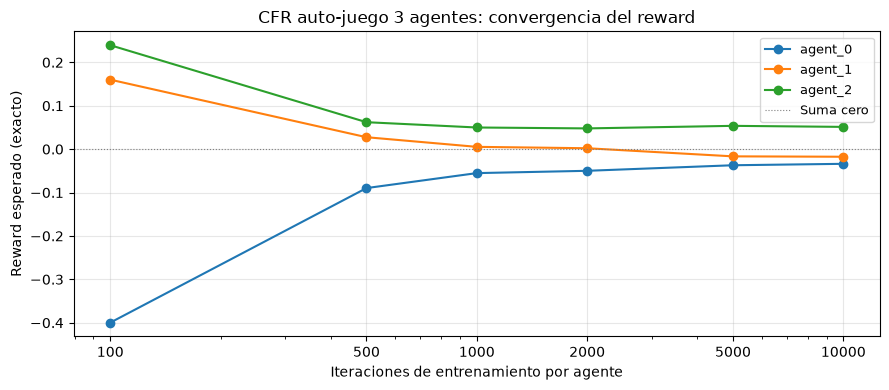

agente  agent_0  agent_1  agent_2
iters                            
100     -0.3997   0.1601   0.2395
500     -0.0897   0.0275   0.0621
1000    -0.0552   0.0053   0.0499
2000    -0.0499   0.0021   0.0478
5000    -0.0371  -0.0166   0.0537
10000   -0.0338  -0.0175   0.0513


In [ ]:
checkpoints = [100, 500, 1000, 2000, 5000]

c0 = CounterFactualRegret(game=game, agent='agent_0')
c1 = CounterFactualRegret(game=game, agent='agent_1')
c2 = CounterFactualRegret(game=game, agent='agent_2')
c1.node_dict = c0.node_dict
c2.node_dict = c0.node_dict

history = {a: [] for a in game.agents}
prev = 0
for ck in checkpoints:
    train_alternated(c0, c1, c2, total_iters=ck - prev, block=min(100, ck - prev))
    prev = ck
    shared = c0.node_dict
    for ag in game.agents:
        history[ag].append(cfr_expected_reward(shared, game, ag))

rows = []
for ag in game.agents:
    for ck, val in zip(checkpoints, history[ag]):
        rows.append(dict(agente=ag, iters=ck, avg_reward=round(val, 4)))
df_exp1 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
colors = {'agent_0': 'tab:blue', 'agent_1': 'tab:orange', 'agent_2': 'tab:green'}
for ag in game.agents:
    vals = [r['avg_reward'] for r in rows if r['agente'] == ag]
    ax.plot(checkpoints, vals, marker='o', label=ag, color=colors[ag])
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, label='Suma cero')
ax.set_xscale('log')
log_xticks(ax, checkpoints)
ax.set_xlabel('Iteraciones de entrenamiento por agente')
ax.set_ylabel('Reward esperado (exacto)')
ax.set_title('CFR auto-juego 3 agentes: convergencia del reward')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'cfr3_autoplay.png')
plt.show()

print(df_exp1.pivot(index='iters', columns='agente', values='avg_reward').to_string())

## Experimento 2 — ISMCTS en auto-juego: efecto del número de simulaciones

Tres agentes ISMCTS juegan entre sí variando `simulations`.
ISMCTS es un algoritmo online: no requiere entrenamiento previo; en cada turno
construye un árbol de búsqueda usando determinizaciones aleatorias de las cartas rivales.

Se mide el reward promedio de cada agente en función de las simulaciones por decisión.

sims=5: agent_0=-0.230  agent_1=0.150  agent_2=0.080
sims=10: agent_0=-0.085  agent_1=-0.005  agent_2=0.090
sims=25: agent_0=0.020  agent_1=-0.055  agent_2=0.035
sims=50: agent_0=0.020  agent_1=-0.005  agent_2=-0.015
sims=100: agent_0=-0.175  agent_1=0.275  agent_2=-0.100
sims=200: agent_0=0.045  agent_1=-0.170  agent_2=0.125
Guardada: ../informe/figures/KuhnPoker3/ismcts3_autoplay.png


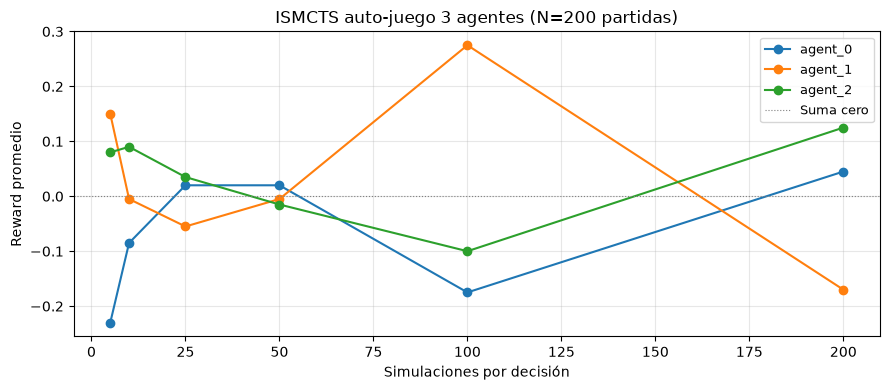

agente,agent_0,agent_1,agent_2
sims,,,
5,-0.230,0.150,0.080
10,-0.085,-0.005,0.090
25,0.020,-0.055,0.035
50,0.020,-0.005,-0.015
100,-0.175,0.275,-0.100
200,0.045,-0.170,0.125


In [12]:
N = 200
sim_grid = [5, 10, 25, 50, 100, 200]
colors = {'agent_0': 'tab:blue', 'agent_1': 'tab:orange', 'agent_2': 'tab:green'}

rows = []
for sims in sim_grid:
    agents = {
        a: InformationSetMCTS(game=game, agent=a, simulations=sims,
                              rollouts=3, sample_from_infoset=kuhn3_sample)
        for a in game.agents
    }
    rewards = {a: [] for a in game.agents}
    for _ in range(N):
        game.reset()
        while not game.terminated():
            a = agents[game.agent_selection].action()
            game.step(a)
        for ag in game.agents:
            rewards[ag].append(game.reward(ag))

    for ag in game.agents:
        r = np.array(rewards[ag])
        rows.append(dict(agente=ag, sims=sims, avg_reward=round(r.mean(), 4)))
    print(f'sims={sims}: ' + '  '.join(f'{ag}={np.mean(rewards[ag]):.3f}' for ag in game.agents))

df_exp2 = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
for ag in game.agents:
    vals = df_exp2[df_exp2.agente == ag]
    ax.plot(vals.sims, vals.avg_reward, marker='o', label=ag, color=colors[ag])
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, label='Suma cero')
ax.set_xlabel('Simulaciones por decisión')
ax.set_ylabel('Reward promedio')
ax.set_title(f'ISMCTS auto-juego 3 agentes (N={N} partidas)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'ismcts3_autoplay.png')
plt.show()

df_exp2.pivot(index='sims', columns='agente', values='avg_reward')

## Experimento 3 — 2 CFR vs 1 ISMCTS

Se pre-entrenan dos agentes CFR (agent_0 y agent_1) con `node_dict` compartido.
El tercer slot (agent_2) lo ocupa ISMCTS con distintos presupuestos de simulación.

Se miden rewards y tiempos de decisión en **5000 partidas** por configuración.

In [13]:
N_EXP3 = 2000
CFR_ITERS = 2000
sim_grid = [10, 25, 50, 100]
colors = {'agent_0': 'tab:blue', 'agent_1': 'tab:orange', 'agent_2': 'tab:green'}

# Pre-entrenar CFR para agent_0 y agent_1
c0 = CounterFactualRegret(game=game, agent='agent_0')
c1 = CounterFactualRegret(game=game, agent='agent_1')
c1.node_dict = c0.node_dict
train_alternated(c0, c1, total_iters=CFR_ITERS, block=100)
print(f'CFR entrenado: {CFR_ITERS} iters, {len(c0.node_dict)} nodos')

rows = []
for sims in sim_grid:
    c2 = InformationSetMCTS(game=game, agent='agent_2', simulations=sims,
                             rollouts=3, sample_from_infoset=kuhn3_sample)
    agents = {'agent_0': c0, 'agent_1': c1, 'agent_2': c2}

    rewards = {a: [] for a in game.agents}
    times   = {a: [] for a in game.agents}

    for _ in range(N_EXP3):
        game.reset()
        while not game.terminated():
            ag = game.agent_selection
            t0 = time.perf_counter()
            a  = agents[ag].action()
            times[ag].append(time.perf_counter() - t0)
            game.step(a)
        for ag in game.agents:
            rewards[ag].append(game.reward(ag))

    for ag in game.agents:
        r = np.array(rewards[ag])
        rows.append(dict(
            sims=sims,
            agente=ag,
            tipo='CFR' if ag != 'agent_2' else f'ISMCTS ({sims})',
            avg_reward=round(r.mean(), 4),
            std=round(r.std(), 4),
            win_pct=round((r > 0).mean() * 100, 1),
            avg_ms=round(np.mean(times[ag]) * 1000, 3),
        ))
    print(f'sims={sims:3d}: ' + '  '.join(
        f'{ag}={np.mean(rewards[ag]):.3f}' for ag in game.agents))

df_exp3 = pd.DataFrame(rows)

# reward por agente vs simulaciones de ISMCTS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ag in game.agents:
    sub = df_exp3[df_exp3.agente == ag]
    label = ag + (' (ISMCTS)' if ag == 'agent_2' else ' (CFR)')
    axes[0].plot(sub.sims, sub.avg_reward, marker='o', label=label, color=colors[ag])
axes[0].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_xlabel('Simulaciones ISMCTS (agent_2)')
axes[0].set_ylabel('Reward promedio')
axes[0].set_title(f'2 CFR vs 1 ISMCTS (N={N_EXP3})')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Tiempo de decisión
for ag in game.agents:
    sub = df_exp3[df_exp3.agente == ag]
    label = ag + (' (ISMCTS)' if ag == 'agent_2' else ' (CFR)')
    axes[1].plot(sub.sims, sub.avg_ms, marker='o', label=label, color=colors[ag])
axes[1].set_xlabel('Simulaciones ISMCTS (agent_2)')
axes[1].set_ylabel('Tiempo promedio por decisión (ms)')
axes[1].set_title('Costo computacional por decisión')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'cfr2_ismcts1.png')
plt.show()

# benchmark
bench = df_exp3[df_exp3.sims == 100][['agente', 'tipo', 'avg_reward', 'std', 'win_pct', 'avg_ms']]
print(f'\nBenchmark fijo (ISMCTS sims=100, N={N_EXP3}):')
print(bench.to_string(index=False))

CFR entrenado: 2000 iters, 48 nodos
sims= 10: agent_0=0.030  agent_1=-0.107  agent_2=0.076
sims= 25: agent_0=0.100  agent_1=-0.161  agent_2=0.061
sims= 50: agent_0=0.064  agent_1=-0.161  agent_2=0.097
sims=100: agent_0=0.113  agent_1=-0.167  agent_2=0.054


KeyboardInterrupt: 

### Conclusiones

